In [146]:
#This notebook is about polynomial regression, which is a type of regression analysis that models the relationship between a dependent variable and one or more independent variables as an nth degree polynomial.
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [147]:
df=pd.read_csv("customersatisfaction.csv")
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [148]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


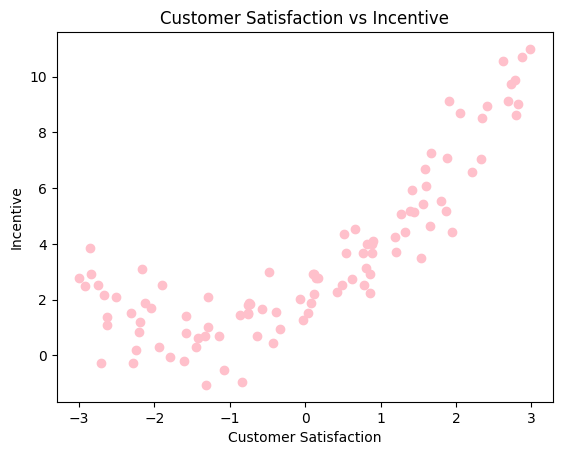

In [150]:
plt.scatter(df["Customer Satisfaction"], df["Incentive"], color="pink")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.title("Customer Satisfaction vs Incentive")
plt.show()

In [151]:
y=df["Incentive"]
X=df[["Customer Satisfaction"]]
lr=LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=34)

In [152]:
X_train

,Customer Satisfaction
40,1.321758
60,1.411586
28,1.191020
64,-2.843812
81,1.806957
...,...
69,-1.070874
35,1.265086
68,-1.794949
85,-2.159425


In [153]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [154]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [155]:
#predictions
y_pred=lr.predict(X_test)
y_pred

array([ 3.47883965,  5.67289106,  1.17647825,  1.41906373,  2.7945071 ,
        0.19725814,  3.52165142,  7.22072351, -0.53961524,  7.48433001,
        4.1175981 ,  2.33328522,  4.60501249, -0.73395561,  4.05356259,
        5.58917204,  4.08377635,  1.20702267,  7.08523278,  2.59274939])

In [156]:
r2_score=r2_score(y_test, y_pred)
r2_score

0.6198179847423941

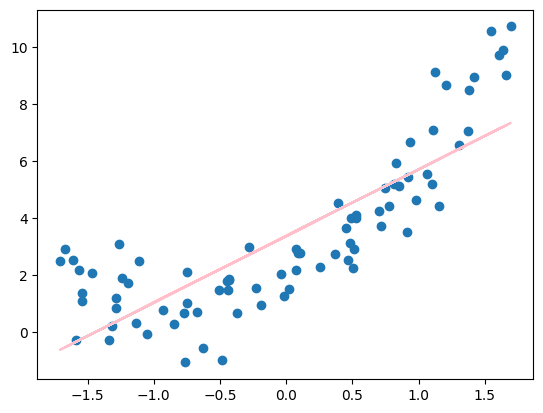

In [157]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color="pink")
plt.show()

In [158]:
ply=PolynomialFeatures()
X_train_poly=ply.fit_transform(X_train)
X_test_poly=ply.transform(X_test)
X_train_poly

array([[ 1.00000000e+00,  7.79129045e-01,  6.07042068e-01],
       [ 1.00000000e+00,  8.31891883e-01,  6.92044104e-01],
       [ 1.00000000e+00,  7.02337177e-01,  4.93277510e-01],
       [ 1.00000000e+00, -1.66761361e+00,  2.78093517e+00],
       [ 1.00000000e+00,  1.06412204e+00,  1.13235572e+00],
       [ 1.00000000e+00, -1.33502866e+00,  1.78230152e+00],
       [ 1.00000000e+00,  1.54511037e+00,  2.38736605e+00],
       [ 1.00000000e+00,  1.38109658e+00,  1.90742775e+00],
       [ 1.00000000e+00,  2.22638065e-02,  4.95677081e-04],
       [ 1.00000000e+00,  1.60928340e+00,  2.58979307e+00],
       [ 1.00000000e+00, -1.13301324e+00,  1.28371899e+00],
       [ 1.00000000e+00,  1.69557928e+00,  2.87498908e+00],
       [ 1.00000000e+00,  4.53058000e-01,  2.05261552e-01],
       [ 1.00000000e+00, -1.60831543e+00,  2.58667852e+00],
       [ 1.00000000e+00, -7.50510392e-01,  5.63265849e-01],
       [ 1.00000000e+00,  5.10342142e-01,  2.60449102e-01],
       [ 1.00000000e+00, -4.29512442e-01

In [159]:
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_poly=lr.predict(X_test_poly)
score=r2_score(y_test, y_pred_poly)
score

0.9164490913435303

In [160]:
lr.coef_

array([0.        , 2.46484028, 1.4877923 ])

In [161]:
lr.intercept_

np.float64(1.8851365528251658)

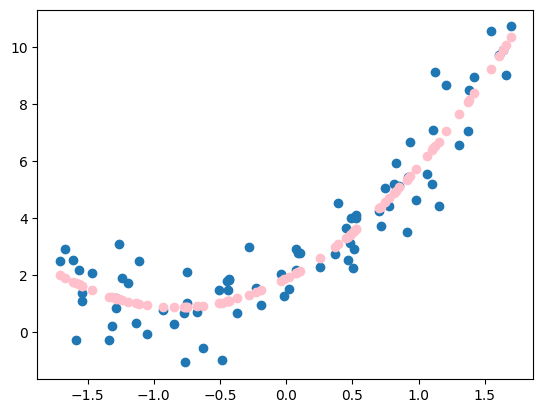

In [162]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, lr.predict(X_train_poly), color="pink")
plt.show()

In [163]:
ply=PolynomialFeatures(degree=3, include_bias=True)
X_train_poly3=ply.fit_transform(X_train)
X_test_poly3=ply.transform(X_test)
X_train_poly3

array([[ 1.00000000e+00,  7.79129045e-01,  6.07042068e-01,
         4.72964107e-01],
       [ 1.00000000e+00,  8.31891883e-01,  6.92044104e-01,
         5.75705873e-01],
       [ 1.00000000e+00,  7.02337177e-01,  4.93277510e-01,
         3.46447134e-01],
       [ 1.00000000e+00, -1.66761361e+00,  2.78093517e+00,
        -4.63752535e+00],
       [ 1.00000000e+00,  1.06412204e+00,  1.13235572e+00,
         1.20496468e+00],
       [ 1.00000000e+00, -1.33502866e+00,  1.78230152e+00,
        -2.37942362e+00],
       [ 1.00000000e+00,  1.54511037e+00,  2.38736605e+00,
         3.68874403e+00],
       [ 1.00000000e+00,  1.38109658e+00,  1.90742775e+00,
         2.63434193e+00],
       [ 1.00000000e+00,  2.22638065e-02,  4.95677081e-04,
         1.10356586e-05],
       [ 1.00000000e+00,  1.60928340e+00,  2.58979307e+00,
         4.16771101e+00],
       [ 1.00000000e+00, -1.13301324e+00,  1.28371899e+00,
        -1.45447061e+00],
       [ 1.00000000e+00,  1.69557928e+00,  2.87498908e+00,
      

In [164]:
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train_poly3, y_train)
y_pred_poly3=lr.predict(X_test_poly3)
score3=r2_score(y_test, y_pred_poly3)
score3

0.9192855559230112

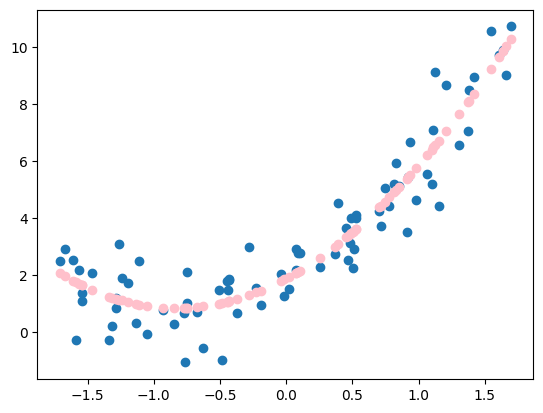

In [165]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, lr.predict(X_train_poly3), color="pink")
plt.show()

In [166]:
new_df=pd.read_csv("newdatas.csv")
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [167]:
new_df.rename(columns={"0":"Customer_Satisfaction"}, inplace=True)
new_df

,Customer_Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [168]:
X_new=new_df[["Customer_Satisfaction"]]
scaler.fit_transform(X_new)
X_new_poly=ply.transform(X_new)
y_new=lr.predict(X_new_poly)
y_new

c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


array([ 8.47819701,  8.26384047,  8.05263929,  7.8445889 ,  7.63968472,
        7.43792217,  7.23929668,  7.04380366,  6.85143854,  6.66219674,
        6.47607369,  6.29306479,  6.11316549,  5.93637119,  5.76267733,
        5.59207931,  5.42457258,  5.26015254,  5.09881462,  4.94055424,
        4.78536682,  4.63324779,  4.48419257,  4.33819657,  4.19525523,
        4.05536397,  3.91851819,  3.78471334,  3.65394483,  3.52620808,
        3.40149851,  3.27981155,  3.16114262,  3.04548715,  2.93284054,
        2.82319823,  2.71655563,  2.61290818,  2.51225129,  2.41458038,
        2.31989087,  2.22817819,  2.13943777,  2.05366501,  1.97085535,
        1.8910042 ,  1.814107  ,  1.74015915,  1.66915609,  1.60109323,
        1.53596599,  1.47376981,  1.41450009,  1.35815227,  1.30472177,
        1.254204  ,  1.20659439,  1.16188836,  1.12008133,  1.08116873,
        1.04514598,  1.0120085 ,  0.98175171,  0.95437103,  0.92986189,
        0.90821971,  0.8894399 ,  0.8735179 ,  0.86044913,  0.85

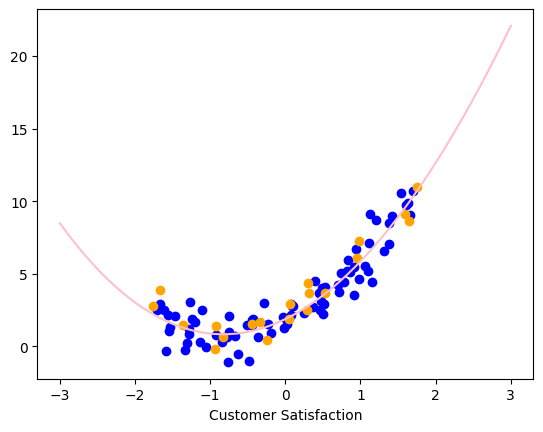

In [169]:
plt.plot(X_new, y_new, color="pink",label="NewPredicted Values")
plt.scatter(X_train, y_train, color="blue", label="Train Data")
plt.scatter(X_test, y_test, color="orange", label="Test Data")
plt.xlabel("Customer Satisfaction") 
plt.show()

In [170]:
#pipeline

def polynomial_regression(degree):
    ply=PolynomialFeatures(degree=degree, include_bias=True)
    lr=LinearRegression()
    pipeline=Pipeline([("polynomial_features", ply), ("linear_regression", lr)])
    pipeline.fit(X_train, y_train)
    score=pipeline.score(X_test, y_test)
    #y_pred_pipeline=pipeline.predict(X_test)
    #score_pipeline=r2_score(y_test, y_pred_pipeline)
    return score

In [175]:
for degrees in [1,2,3,4,5,6,7,8,9,10]:
    score = polynomial_regression(degrees)
    print(score)

0.6198179847423941
0.9164490913435303
0.9192855559230112
0.9222916535892983
0.9232457667069175
0.9202655346258339
0.9181244052691324
0.9240537567204306
0.8990970991834818
0.8975888978919522
